# EXP6 — Variance-head results (streamflow first, calibration last)

Deliberate order: **understand the uncertainty hydrologically before any ML metric.**
1. Event hydrographs at the 2021 extremes. 2. Where the uncertainty lives (map).
3. Uncertainty by glaciation class (bridge to EXP4a). 4. Predicted vs realized error by
flow. 5. **Only then**: formal calibration (PIT + regime coverage). PIT answers what the
magnitude plots can't — do the intervals actually *cover*, given the shape.

In [10]:
# Cell 1: imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

from src.config import OUTPUT_DATA_DIR, PROCESSED_DATA_DIR
RESULTS = OUTPUT_DATA_DIR / "results_MVE"; VAR = RESULTS / "variance"
EVENTS = {"heat_dome_2021": ("2021-06-01","2021-07-31"),
          "ar_flood_2021":  ("2021-10-20","2021-12-10")}

In [11]:
# Cell 2: load grids + station attributes, aligned on the (date, station) grid
idx = pd.read_csv(RESULTS/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(RESULTS/"y_obs_mm.npy"); valid = np.load(RESULTS/"valid_mask.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2, sigma_a2, var_total = pred["mu_hat"], pred["sigma_e2"], pred["sigma_a2"], pred["var_total"]
stations = pd.read_csv(RESULTS/"q_std.csv")["station_id"].astype(str).to_numpy()
S = len(stations); test = (split=="test")[:,None] & valid
sig_tot, sig_e, sig_a = np.sqrt(var_total), np.sqrt(sigma_e2), np.sqrt(sigma_a2)

stat = pd.read_csv(PROCESSED_DATA_DIR/"static_attributes.csv")
stat["station_id"] = stat["station_id"].astype(str)
stat = stat.set_index("station_id").reindex(stations)
gp, lon, lat = stat["glacier_pct"].to_numpy(), stat["longitude"].to_numpy(), stat["latitude"].to_numpy()
GLAC = np.select([gp==0,(gp>0)&(gp<1),(gp>=1)&(gp<=5),gp>5],
                 ["non","low (<1%)","med (1-5%)","high (>5%)"], default="na")
GORDER = ["non","low (<1%)","med (1-5%)","high (>5%)"]

def per_station_median(a):
    out = np.full(S, np.nan)
    for j in range(S):
        m = test[:,j]
        if m.any(): out[j] = np.median(a[m,j])
    return out
print("grid", y.shape, "| test+valid cells", int(test.sum()))

grid (15706, 269) | test+valid cells 877729


## 1. Event hydrographs — the 2021 extremes
obs vs ensemble mean μ̂ with three nested bands: σ_e (ensemble), σ_a (variance head),
σ_total. Read the mean shrinkage, the sliver-thin ensemble band, and whether anything
reaches the peak.

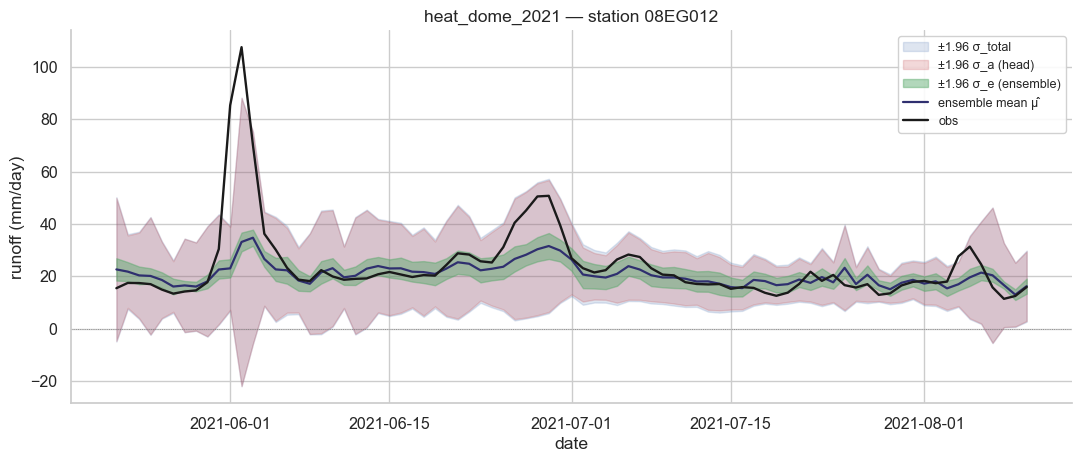

heat_dome_2021 st 08EG012: peak obs 107.6 | μ̂ 33.1 (μ̂/obs 0.31) | covered=False | σ_a 28.1 vs σ_e 1.8


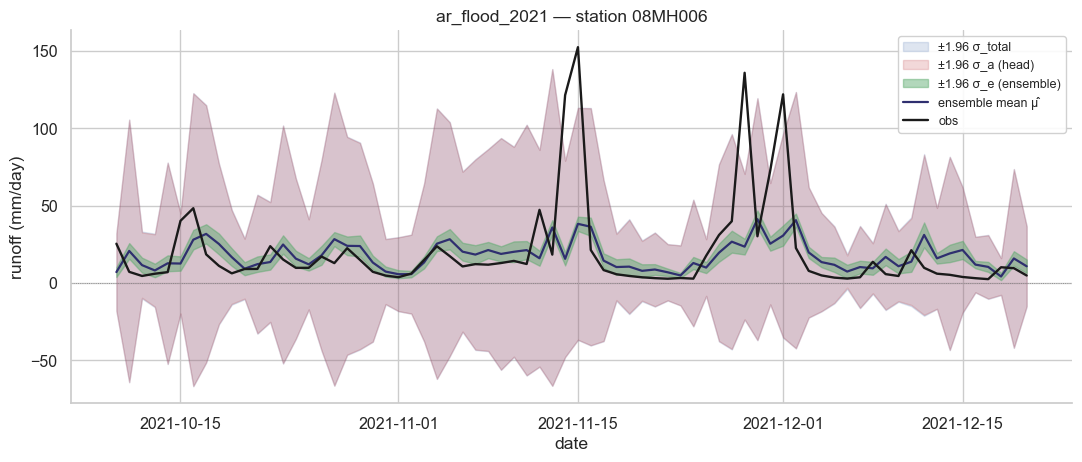

ar_flood_2021 st 08MH006: peak obs 152.5 | μ̂ 38.3 (μ̂/obs 0.25) | covered=False | σ_a 38.2 vs σ_e 2.4


In [12]:
# Cell 3: Q-extreme hydrographs
Z = 1.96
pal = dict(total="#4c72b0", ale="#c44e52", epi="#55a868", mu="#2f2f6f")
def plot_event(name, a, b, station=None, pad_days=10):
    w = (dates >= pd.Timestamp(a)-pd.Timedelta(days=pad_days)) & (dates <= pd.Timestamp(b)+pd.Timedelta(days=pad_days))
    wi = np.where(w)[0]
    if station is None:
        core = (dates>=a)&(dates<=b)
        j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    else:
        j = int(np.where(stations==station)[0][0])
    d=dates[wi]; o=y[wi,j]; m=mu[wi,j]; sT=sig_tot[wi,j]; sE=sig_e[wi,j]; sA=sig_a[wi,j]
    fig,ax=plt.subplots(figsize=(11,4.8))
    ax.fill_between(d,m-Z*sT,m+Z*sT,color=pal["total"],alpha=.18,label="±1.96 σ_total")
    ax.fill_between(d,m-Z*sA,m+Z*sA,color=pal["ale"],alpha=.22,label="±1.96 σ_a (head)")
    ax.fill_between(d,m-Z*sE,m+Z*sE,color=pal["epi"],alpha=.45,label="±1.96 σ_e (ensemble)")
    ax.plot(d,m,color=pal["mu"],lw=1.6,label="ensemble mean μ̂")
    ax.plot(d,o,color="k",lw=1.7,label="obs")
    ax.axhline(0,color="grey",lw=.6,ls=":")
    ax.set(title=f"{name} — station {stations[j]}",xlabel="date",ylabel="runoff (mm/day)")
    ax.legend(fontsize=9, framealpha=.9); sns.despine(ax=ax); plt.tight_layout(); plt.show()
    dc=(d>=pd.Timestamp(a))&(d<=pd.Timestamp(b)); pk=int(np.nanargmax(np.where(dc,o,np.nan)))
    print(f"{name} st {stations[j]}: peak obs {o[pk]:.1f} | μ̂ {m[pk]:.1f} (μ̂/obs {m[pk]/o[pk]:.2f}) "
          f"| covered={o[pk] <= m[pk]+Z*sT[pk]} | σ_a {sA[pk]:.1f} vs σ_e {sE[pk]:.1f}")
for _n,(_a,_b) in EVENTS.items(): plot_event(_n,_a,_b)

## 2. Where does the uncertainty live?
Per-station median predictive σ (mm/day) and epistemic share, on a BC/Alberta basemap.

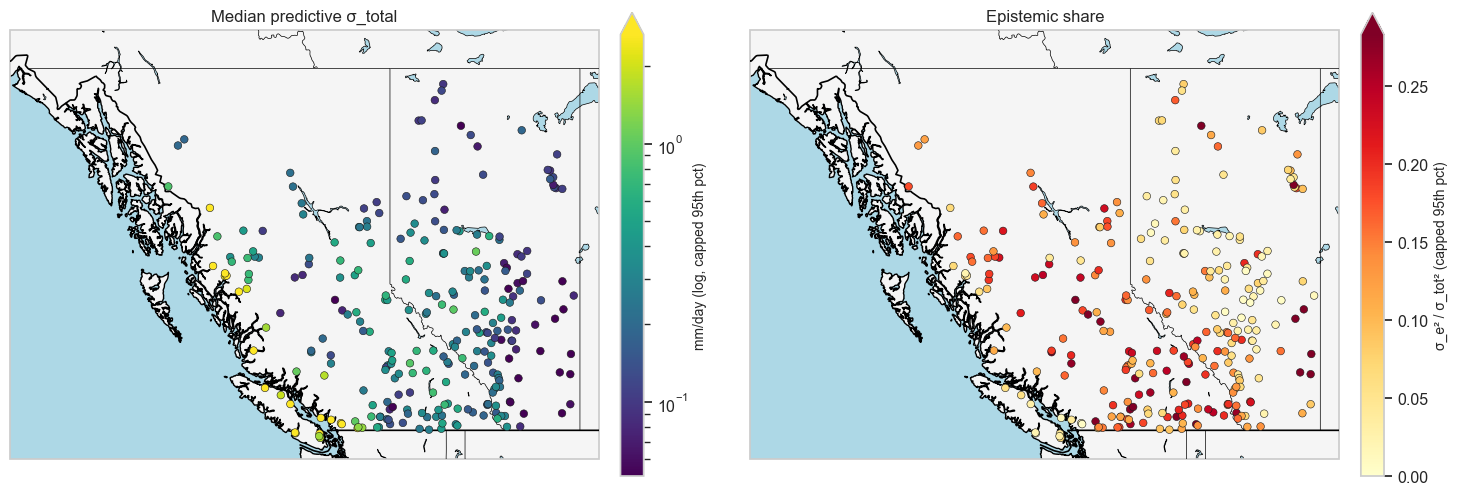

In [13]:
# Cell 4: spatial maps (EXP4a basemap style: Mercator, 10m features, robust caps)
med_stot = per_station_median(sig_tot); epi_share = per_station_median(sigma_e2/var_total)
RES = "10m"
def draw_base(ax):
    ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale(RES), facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale(RES), facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(RES), edgecolor="black", zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale(RES), facecolor="lightblue", edgecolor="black", linewidth=0.5, zorder=2)
    provs = cfeature.NaturalEarthFeature("cultural", "admin_1_states_provinces_lines", scale=RES, facecolor="none")
    ax.add_feature(provs, edgecolor="black", linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale(RES), edgecolor="black", linewidth=1.2, zorder=3)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": ccrs.Mercator()})
# robust caps (95th pct) so a few flashy basins do not wash out the scale (matches EXP4a)
vmax_s = float(np.nanpercentile(med_stot, 95)); vmin_s = float(np.nanpercentile(med_stot[med_stot > 0], 5))
share_max = float(np.nanpercentile(epi_share, 95))
panels = [("Median predictive σ_total", "mm/day (log, capped 95th pct)", med_stot, "viridis",
           mcolors.LogNorm(vmin=vmin_s, vmax=vmax_s)),
          ("Epistemic share", "σ_e² / σ_tot² (capped 95th pct)", epi_share, "YlOrRd",
           mcolors.Normalize(0, share_max))]
for ax, (title, clab, vals, cmap, cnorm) in zip(axes, panels):
    draw_base(ax)
    sc = ax.scatter(lon, lat, c=vals, cmap=cmap, norm=cnorm, s=30, marker="o",
                    edgecolors="k", linewidths=0.4, zorder=5, transform=ccrs.PlateCarree())
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.03, extend="max")
    cb.set_label(clab, fontsize=10)
    ax.set_title(title, fontsize=12)
plt.tight_layout(); plt.show()

## 3. Uncertainty by glaciation class (EXP4a bridge)
Physical thresholds (non / <1% / 1–5% / >5%). Do glacier-fed basins carry distinct
uncertainty structure?

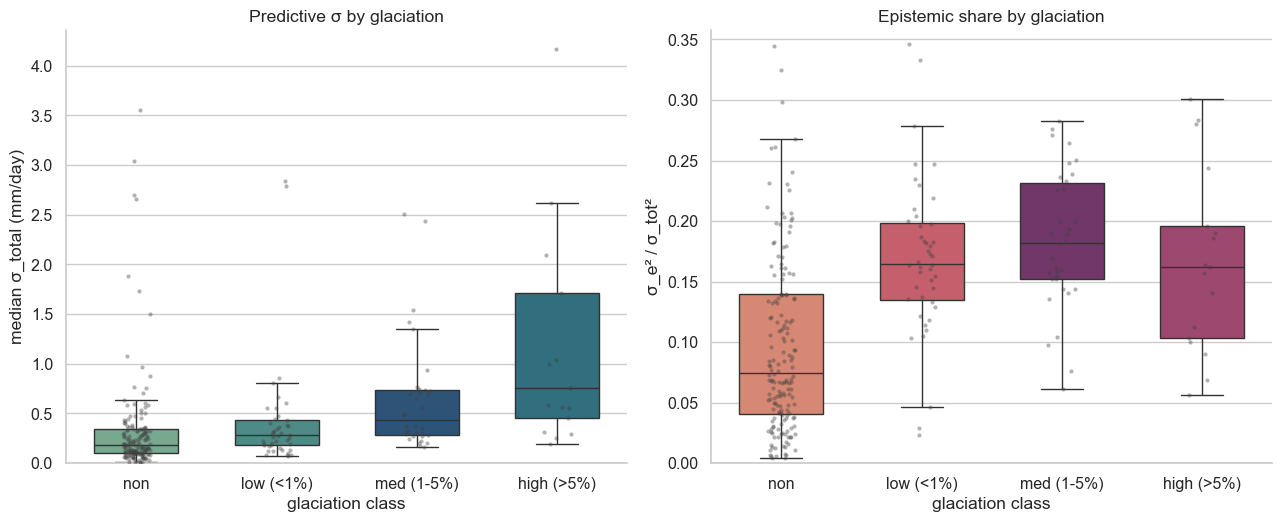

non         n=174  median σ_total 0.184
low (<1%)   n= 44  median σ_total 0.283
med (1-5%)  n= 34  median σ_total 0.431
high (>5%)  n= 17  median σ_total 0.755


In [14]:
# Cell 5: sigma by glaciation class (seaborn; y capped at 97.5th pct so flashy basins do not squash the boxes)
dfg = pd.DataFrame({"glac": GLAC, "median σ_total": med_stot, "epistemic share": epi_share})
dfg = dfg[dfg["glac"] != "na"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, (col, pal_) in zip(axes, [("median σ_total", "crest"), ("epistemic share", "flare")]):
    cap = float(np.nanpercentile(dfg[col], 97.5))
    sns.boxplot(data=dfg, x="glac", y=col, order=GORDER, hue="glac", palette=pal_,
                legend=False, showfliers=False, width=.6, ax=ax)
    sns.stripplot(data=dfg, x="glac", y=col, order=GORDER, color="0.25", size=3, alpha=.4, ax=ax)
    ax.set_ylim(0, cap); ax.set_xlabel("glaciation class")
axes[0].set(title="Predictive σ by glaciation", ylabel="median σ_total (mm/day)")
axes[1].set(title="Epistemic share by glaciation", ylabel="σ_e² / σ_tot²")
sns.despine(fig); plt.tight_layout(); plt.show()
for c in GORDER:
    print(f"{c:11s} n={int((GLAC==c).sum()):3d}  median σ_total {np.nanmedian(med_stot[GLAC==c]):.3f}")

## 4. Does the variance make physical sense? — predicted vs realized error by flow
Both RMS-consistent: predicted = √E[σ_total²], realized = √E[(y−μ̂)²], per within-basin flow
decile. Predicted is *generous* through the body and about-right in *magnitude* at the top
decile — so the variance scale is reasonable. That is exactly why magnitude alone can't tell
us if we're calibrated: the peaks can still escape on **shape**. → coverage check next.

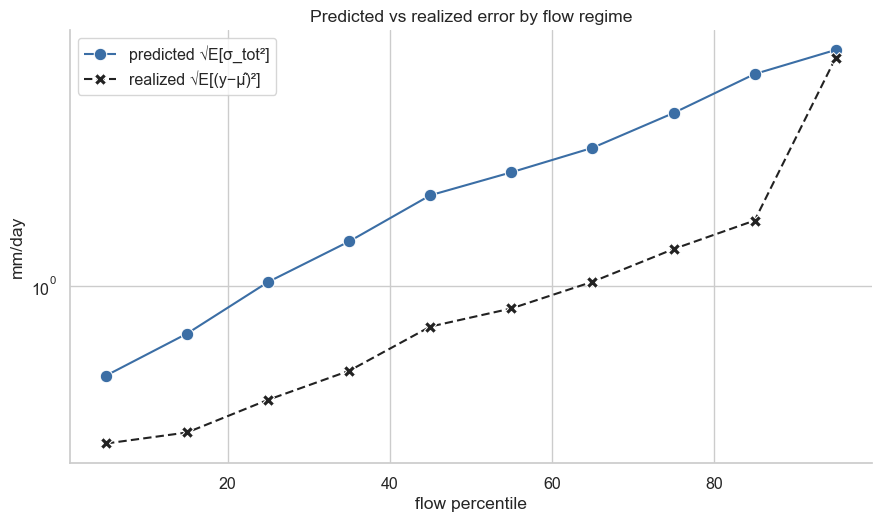

0-10%: predicted 0.508  realized 0.305  ratio 1.67
10-20%: predicted 0.697  realized 0.331  ratio 2.10
20-30%: predicted 1.028  realized 0.424  ratio 2.43
30-40%: predicted 1.395  realized 0.527  ratio 2.65
40-50%: predicted 1.972  realized 0.735  ratio 2.68
50-60%: predicted 2.344  realized 0.842  ratio 2.78
60-70%: predicted 2.818  realized 1.029  ratio 2.74
70-80%: predicted 3.661  realized 1.316  ratio 2.78
80-90%: predicted 4.908  realized 1.631  ratio 3.01
90-100%: predicted 5.885  realized 5.549  ratio 1.06
in-distribution resolution: Spearman(predicted σ_a, |residual|) = 0.74 -> larger predicted σ ⟺ larger actual error; the head resolves error (rules out a too-weak head, Branch C)


In [15]:
# Cell 6: predicted vs realized error by flow regime (seaborn)
pct = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
NB=10; tb = test & np.isfinite(pct); bi = np.clip(np.nan_to_num(pct)*NB,0,NB-1).astype(int)
ctr,predv,realv=[],[],[]
for k in range(NB):
    sel = tb & (bi==k)
    if sel.sum()==0: continue
    predv.append(np.sqrt(np.mean(var_total[sel]))); realv.append(np.sqrt(np.mean((y-mu)[sel]**2))); ctr.append((k+0.5)*10)
dff = pd.DataFrame({"flow percentile":ctr*2, "mm/day":predv+realv,
                    "":["predicted √E[σ_tot²]"]*len(ctr)+["realized √E[(y−μ̂)²]"]*len(ctr)})
fig,ax=plt.subplots(figsize=(9,5.4))
sns.lineplot(data=dff, x="flow percentile", y="mm/day", hue="", style="",
             markers=True, dashes=[(1,0),(4,2)], markersize=9, palette=["#3b6ea5","#222222"], ax=ax)
ax.set(title="Predicted vs realized error by flow regime", yscale="log")
sns.despine(fig); plt.tight_layout(); plt.show()
for c,p,r in zip(ctr,predv,realv): print(f"{int(c-5)}-{int(c+5)}%: predicted {p:.3f}  realized {r:.3f}  ratio {p/r:.2f}")

# in-distribution resolution: does a larger predicted sigma correspond to a larger actual error?
from scipy.stats import spearmanr
ev = np.zeros(len(dates), bool)
for a,b in EVENTS.values(): ev |= (dates>=pd.Timestamp(a)) & (dates<=pd.Timestamp(b))
indist = test & ~ev[:,None]
rho = spearmanr(sig_a[indist], np.abs((y-mu)[indist])).statistic
print(f"in-distribution resolution: Spearman(predicted σ_a, |residual|) = {rho:.2f} "
      "-> larger predicted σ ⟺ larger actual error; the head resolves error (rules out a too-weak head, Branch C)")


## 5. Formal calibration — do the intervals actually cover?
Now, and only now, the ML metric. **PIT** = the observation's position in its own predictive CDF; if honest, PIT is **uniform on [0,1]**. A central hump = intervals too wide; a spike at **1.0** = observations in the far upper tail = under-covering the high side. Coverage is then read by flow regime — the tail is where it fails.

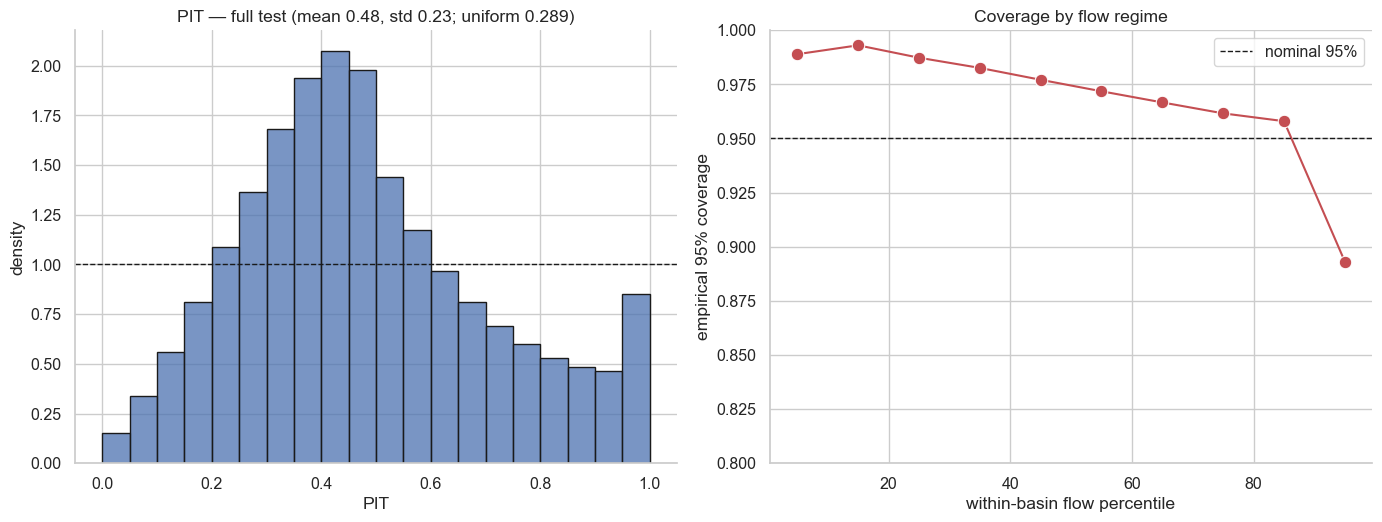

top-decile 95% coverage: 0.893 (nominal 0.95)  <- the tail under-covers
heat_dome_2021: 95% coverage 0.985  (n=16409)
ar_flood_2021: 95% coverage 0.952  (n=10656)


In [16]:
# Cell 7: PIT (full test) + coverage by flow regime (seaborn)
z = (y - mu) / sig_tot
pit = norm.cdf(z[test])
fig,axes=plt.subplots(1,2,figsize=(14,5.4))
sns.histplot(pit, bins=20, stat="density", edgecolor="k", color="#4c72b0", ax=axes[0])
axes[0].axhline(1, ls="--", c="k", lw=1)
axes[0].set(xlabel="PIT", ylabel="density",
            title=f"PIT — full test (mean {pit.mean():.2f}, std {pit.std():.2f}; uniform 0.289)")
zc = norm.ppf(0.975); cov=[]; cc=[]
for k in range(10):
    sel = tb & (bi==k)
    if sel.sum()==0: continue
    cov.append(np.mean(np.abs((y-mu)[sel]) <= zc*sig_tot[sel])); cc.append((k+0.5)*10)
sns.lineplot(x=cc, y=cov, marker="o", markersize=9, color="#c44e52", ax=axes[1])
axes[1].axhline(0.95, ls="--", c="k", lw=1, label="nominal 95%")
axes[1].set(xlabel="within-basin flow percentile", ylabel="empirical 95% coverage",
            title="Coverage by flow regime", ylim=(0.8,1.0)); axes[1].legend()
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"top-decile 95% coverage: {cov[-1]:.3f} (nominal 0.95)  <- the tail under-covers")
for name,(a,b) in EVENTS.items():
    m=((dates>=a)&(dates<=b))[:,None]&valid
    print(f"{name}: 95% coverage {np.mean(np.abs((y-mu)[m])<=zc*sig_tot[m]):.3f}  (n={int(m.sum())})")

## 6. Diagnostic — *why* does the tail fail? (head-too-weak vs D-blind)

Two explanations for the tail under-coverage. 

**"Head too weak" (Branch C)** — a flat, uninformative σ — is already ruled out in Section 4: predicted σ tracks the actual error and resolves it (in-distribution Spearman 0.74). 

That leaves **D-blind**: the uncertainty *fails to inflate* where it matters. The check below shows the blindness is specifically the **ensemble / epistemic** channel.

**Is the *epistemic* uncertainty honest in the tail? (the ensemble D-blindness).**
One-sided tail exceedance = fraction of obs above the 95% upper bound (nominal 2.5%), by flow regime, using the ensemble spread σ_e **alone** vs the full predictive σ_total. 

An honest epistemic proxy would stay near nominal. Instead ensemble-only exceedance **explodes at high flow (≈39% in the top decile)** — the field-standard "ensemble spread = epistemic uncertainty" is confidently wrong in the tail (a direct, aggregate counter to deep-ensembles ≈ Bayesian marginalization). 

The aleatoric head cuts it sharply (≈10%), but a residual tail gap remains — the symmetric Gaussian can't cover the right-skewed peak (Branch B → CMAL). NB this is a high-flow property throughout; the 2021 events (Section 1) are its severe, risk-relevant instances, not a separate failure mode.

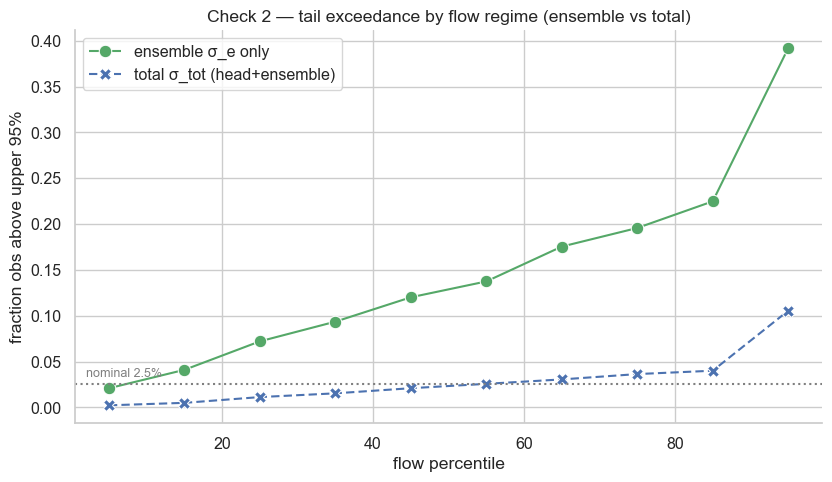

top decile: ensemble 39.2% vs total 10.5% of obs exceed the upper 95% (nominal 2.5%)
ensemble spread is confidently wrong in the tail (D-blind epistemic); the head cuts it sharply,
but a residual tail gap remains -> symmetric Gaussian can't cover the right-skewed peak (Branch B -> CMAL).


In [17]:
# Check: tail exceedance by flow — ensemble σ_e vs total σ_tot  (shows the ensemble D-blindness)
pctB = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
biB  = np.clip(np.nan_to_num(pctB)*10, 0, 9).astype(int)
ctrB, exc_e, exc_t = [], [], []
for k in range(10):
    sel = test & np.isfinite(pctB) & (biB==k)
    if sel.sum()==0: continue
    r = (y - mu)[sel]
    exc_e.append(np.mean(r > 1.96*sig_e[sel]))      # % obs above ensemble-only upper 95%
    exc_t.append(np.mean(r > 1.96*sig_tot[sel]))    # % obs above total upper 95%
    ctrB.append((k+0.5)*10)
dfb = pd.DataFrame({"flow percentile":ctrB*2, "fraction obs above upper 95%":exc_e+exc_t,
                    "":["ensemble σ_e only"]*len(ctrB)+["total σ_tot (head+ensemble)"]*len(ctrB)})
fig,ax=plt.subplots(figsize=(8.5,5))
sns.lineplot(data=dfb, x="flow percentile", y="fraction obs above upper 95%", hue="", style="",
             markers=True, dashes=[(1,0),(4,2)], markersize=9, palette=["#55a868","#4c72b0"], ax=ax)
ax.axhline(0.025, ls=":", c="grey"); ax.text(2, 0.033, "nominal 2.5%", color="grey", fontsize=9)
ax.set(title="Check 2 — tail exceedance by flow regime (ensemble vs total)")
sns.despine(fig); plt.tight_layout(); plt.show()
print(f"top decile: ensemble {exc_e[-1]:.1%} vs total {exc_t[-1]:.1%} of obs exceed the upper 95% (nominal 2.5%)")
print("ensemble spread is confidently wrong in the tail (D-blind epistemic); the head cuts it sharply,")
print("but a residual tail gap remains -> symmetric Gaussian can't cover the right-skewed peak (Branch B -> CMAL).")

**Takeaway.** Uncertainty is largest in glacier-fed/coastal basins and grows with flow (physical). 

The head is *competent* (Check 1: σ_a resolves the error, Spearman 0.74 — not Branch C) and its magnitude is reasonable-to-generous. 

The failure is in the tail and it is two-fold: 
- the **ensemble epistemic proxy is confidently wrong** (≈39% of top-decile obs escape its 95% band — ensemble spread is not honest epistemic uncertainty) 
- even the head's **symmetric** predictive can't cover the right-skewed peak (≈10% residual exceedance; the 2021 events are the severe instances). 

That motivates the aleatoric-shape (CMAL) and formal-epistemic (Bayesian) fork.